# Classification Track Preprocessing & EDA
**Dataset**: Dry Bean Dataset

## Section A - Dataset & EDA
### A1: Dataset loading & audit

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')

# Load dataset
df = pd.read_csv('../data/Dry_Bean_Dataset.csv')

print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)


Dataset Shape: (13611, 17)

Data Types:
Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class                  str
dtype: object


In [3]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64


In [4]:
print("\nClass Distribution:")
print(df['Class'].value_counts())


Class Distribution:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


### A2 & A3: EDA Visualisations & Insight Commentary

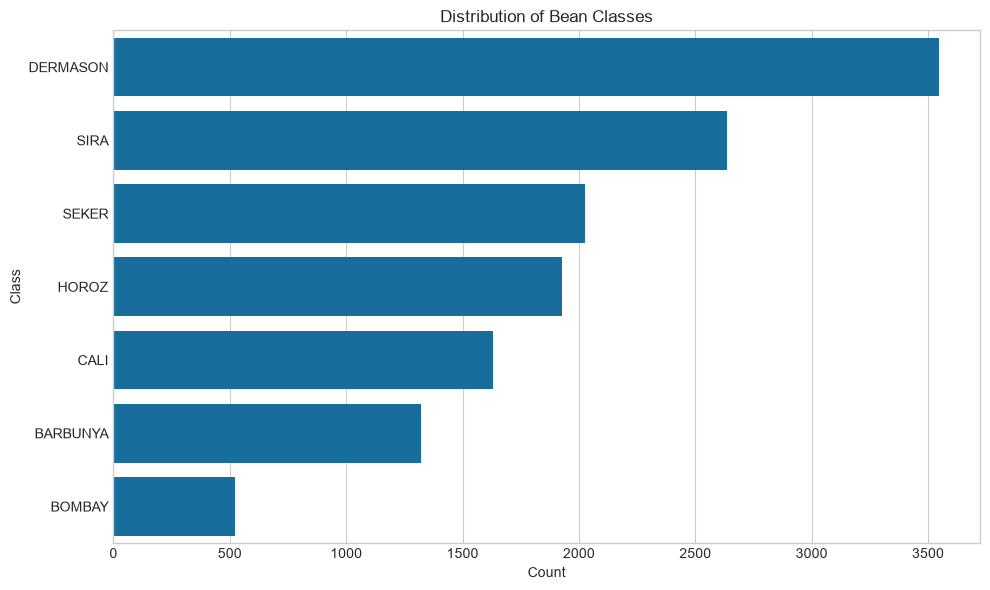

In [5]:
# Target Distribution
plt.figure(figsize=(10, 6))
sns.countplot(y='Class', data=df, order=df['Class'].value_counts().index)
plt.title('Distribution of Bean Classes')
plt.xlabel('Count')
plt.ylabel('Class')
plt.tight_layout()
plt.show()


**Observation (Target Distribution):** The dataset is somewhat imbalanced. The `DERMASON` class is the most frequent, while `BOMBAY` is the rarest. We will use a stratified split to handle this.

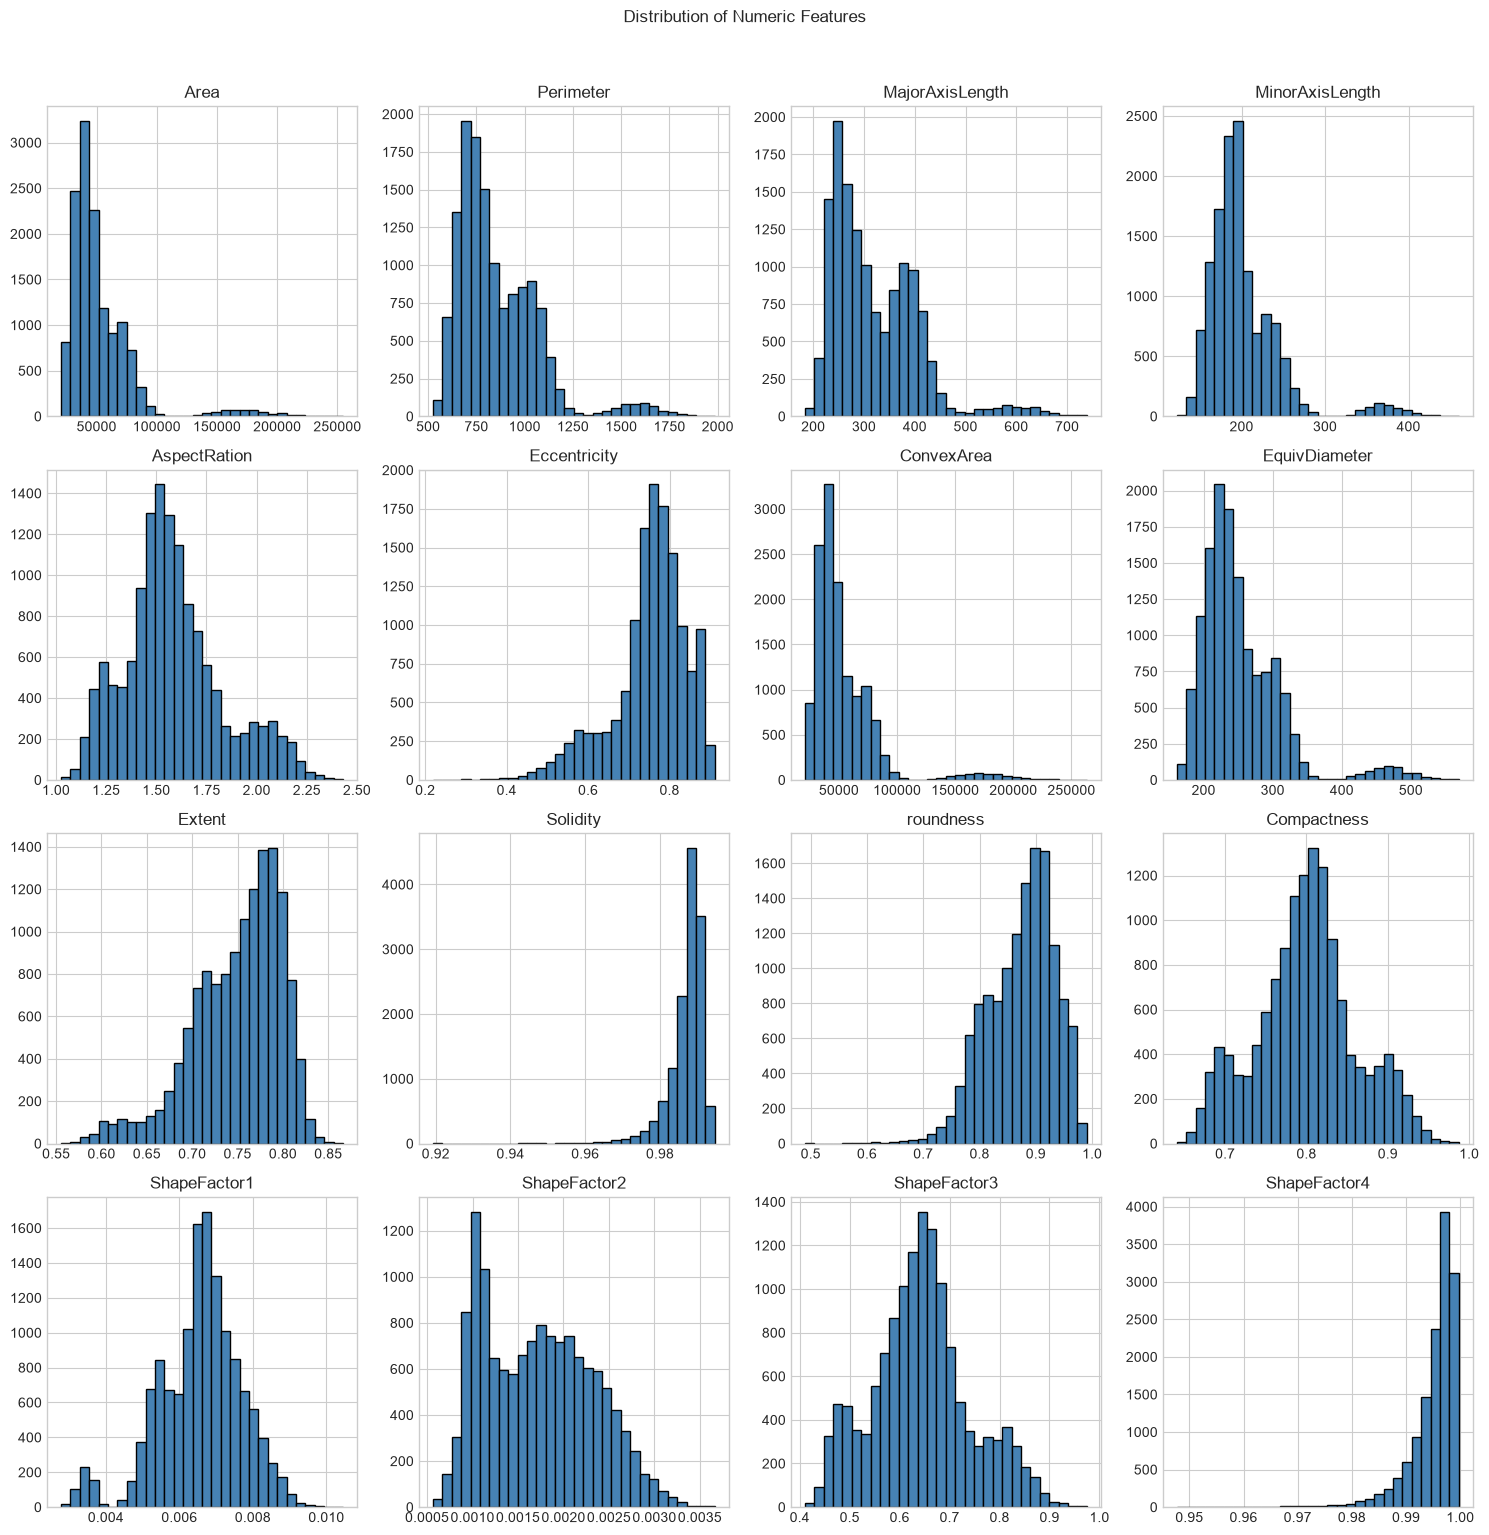

In [6]:
# Feature Distributions (Histograms)
numeric_features = df.select_dtypes(include=[np.number]).columns
df[numeric_features].hist(bins=30, figsize=(15, 15), color='steelblue', edgecolor='black')
plt.suptitle('Distribution of Numeric Features', y=1.02)
plt.tight_layout()
plt.show()


**Observation (Distributions):** Several features like `Area`, `ConvexArea`, and `Perimeter` are right-skewed, while `Solidity` and `Extent` are left-skewed. Outliers exist in the tails, which we will address during data cleaning.

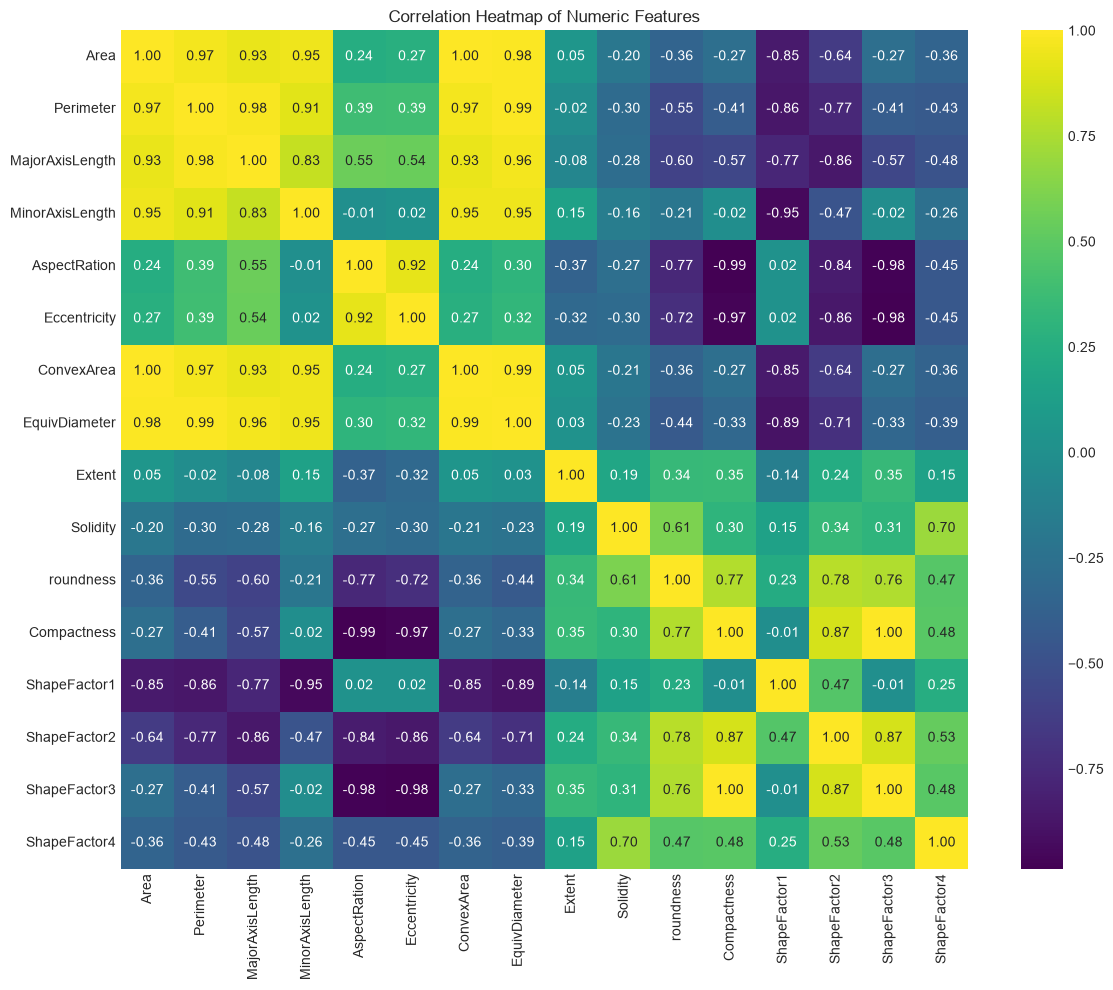

In [8]:
# Correlation Heatmap
plt.figure(figsize=(12, 10))
corr = df[numeric_features].corr()
sns.heatmap(corr, annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()


**Observation (Correlation):** There is high multicollinearity among size-related features (`Area`, `Perimeter`, `MajorAxisLength`, `ConvexArea`, `EquivDiameter`). Shape factors (`ShapeFactor1`, `ShapeFactor2`) are negatively correlated with size features.

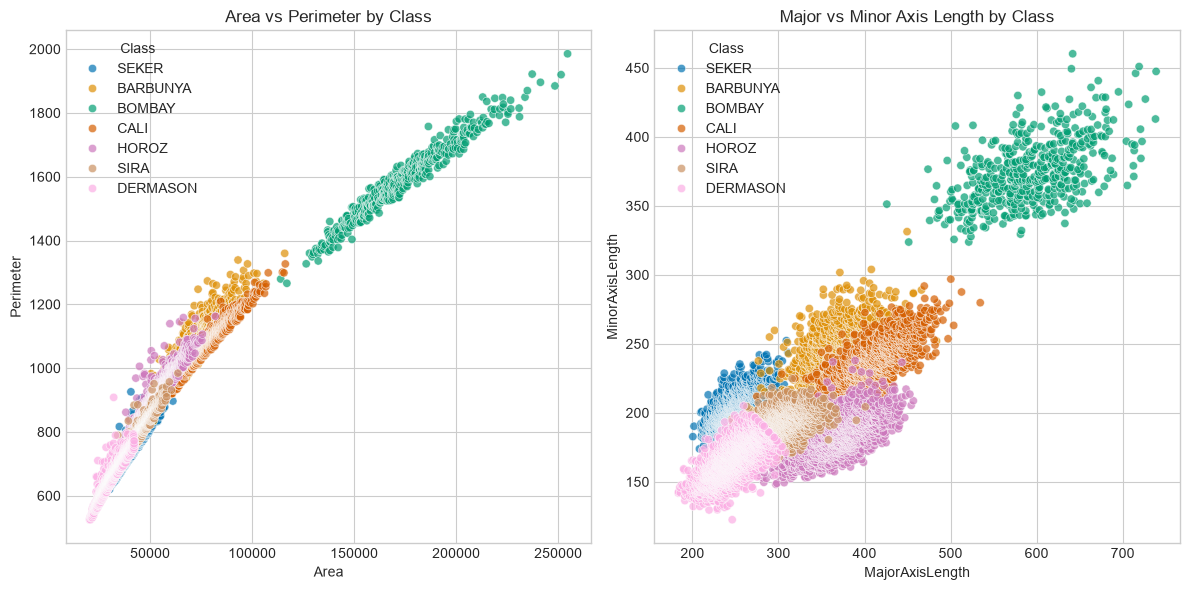

In [9]:
# Scatter Plots showing Feature-Target Relationships
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='Area', y='Perimeter', hue='Class', data=df, palette='colorblind', alpha=0.7)
plt.title('Area vs Perimeter by Class')

plt.subplot(1, 2, 2)
sns.scatterplot(x='MajorAxisLength', y='MinorAxisLength', hue='Class', data=df, palette='colorblind', alpha=0.7)
plt.title('Major vs Minor Axis Length by Class')

plt.tight_layout()
plt.show()


**Observation (Scatter Plots):** The scatter plots reveal clear separable clusters for certain classes (like BOMBAY, which is distinctively large in Area and Perimeter). Other classes (like SEKER and DERMASON) cluster closely but have slight differences in their axis lengths.

## Section B - Preprocessing & Feature Engineering
### B1: Data cleaning

In [10]:
# Handle Duplicates
initial_shape = df.shape
df = df.drop_duplicates()
print(f"Removed {initial_shape[0] - df.shape[0]} duplicate rows. New shape: {df.shape}")

# Handle Outliers (using IQR method for numeric columns)
Q1 = df[numeric_features].quantile(0.25)
Q3 = df[numeric_features].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create a mask for rows that are NOT outliers
mask = ~((df[numeric_features] < lower_bound) | (df[numeric_features] > upper_bound)).any(axis=1)
df_cleaned = df[mask].copy()

print(f"Removed {df.shape[0] - df_cleaned.shape[0]} outlier rows. Cleaned shape: {df_cleaned.shape}")


Removed 68 duplicate rows. New shape: (13543, 17)
Removed 3004 outlier rows. Cleaned shape: (10539, 17)


### B3: Feature Engineering

Created a new feature to provide a basic geometric measure of how dense or how circular the bean is. While complex shape factors exist in the dataset, this raw ratio can offer a highly interpretable linear feature for simpler models like Logistic Regression.

In [ ]:
df_cleaned['Area_Perimeter_Ratio'] = df_cleaned['Area'] / df_cleaned['Perimeter']
print("Engineered feature 'Area_Perimeter_Ratio' created.")


Engineered feature 'Area_Perimeter_Ratio' created.


### B2: Encoding, scaling & splitting

In [12]:
# Encoding Target
le = LabelEncoder()
X = df_cleaned.drop('Class', axis=1)
y = le.fit_transform(df_cleaned['Class'])

# Map for reference
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Class Mapping:", class_mapping)

# Stratified Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling (Fitted on Train ONLY to prevent data leakage)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")


Class Mapping: {'BARBUNYA': np.int64(0), 'CALI': np.int64(1), 'DERMASON': np.int64(2), 'HOROZ': np.int64(3), 'SEKER': np.int64(4), 'SIRA': np.int64(5)}
X_train shape: (8431, 17)
X_test shape: (2108, 17)


In [13]:
# Save preprocessed data
os.makedirs('../data/classification', exist_ok=True)
X_train_scaled.to_csv('../data/classification/X_train.csv', index=False)
X_test_scaled.to_csv('../data/classification/X_test.csv', index=False)
pd.DataFrame(y_train, columns=['Class']).to_csv('../data/classification/y_train.csv', index=False)
pd.DataFrame(y_test, columns=['Class']).to_csv('../data/classification/y_test.csv', index=False)

print("Preprocessed data saved to data/classification/ directory.")


Preprocessed data saved to data/classification/ directory.
